## Mini Project #4

James Levi, 10/22/2025

The following two images are captured from a biological specimen. Both images are mixed and
distorted by the same random image as shown in the figures

<p align = "center">
<img src="Recordings.png" width="700">
</p>


Download these two images (Recording-1.png and Recording-2.png) from Canvas. Then use the
ICA algorithm to separate the distortion from the main image. Implement Fast-ICA algorithm
for noise separation.

<p align = "center">
<img src="Solution.png" width="700">
</p>

In [117]:
from PIL import Image
import numpy as np


In [118]:
from PIL import Image
import numpy as np

def convert_image_to_vector(image_path):
    #Converts an image into a 1D vector of pixel values.
    #Automatically stores and returns the original shape for later reconstruction.

    img = Image.open(image_path).convert("L")       # Convert to grayscale
    arr = np.array(img, dtype=np.float64)           # 2D array of pixel values
    vector = arr.flatten()                          # Flatten into 1D vector
    return vector, arr.shape                        # Return both vector and original shape


def convert_vector_to_image(vector, shape):
    # Rescale to 0–255 so it's displayable as an 8-bit image
    v = vector.astype(np.float64).copy()
    v -= v.min()
    vmax = v.max()
    if vmax > 0:
        v /= vmax
    v = (v * 255).astype(np.uint8)
    return Image.fromarray(v.reshape(shape), mode="L")



In [119]:
x1, shape1 = convert_image_to_vector("Recording-1.png") #first row of X
x2, shape2 = convert_image_to_vector("Recording-2.png") #second row of X

# Stack the two 1D recordings as rows to form a 2 x N matrix
X = np.vstack((x1, x2)).astype(np.float64)

# Center each row by subtracting its mean
X_center = X - X.mean(axis=1, keepdims=True)  # axis=1 for row-wise mean


In [120]:
#Covariance Matrix for Recording1 and Recording 2
C = (X_center @ X_center.T)/X.shape[1]

In [121]:
# Eigenvalue decomposition for 2X2 Covariance Matrix.
a, b, c, d = C.flatten()
disc = (a - d)**2 + 4 * b * c
lambda1 = ((a + d) + np.sqrt(disc)) / 2
lambda2 = ((a + d) - np.sqrt(disc)) / 2

eigvals = [lambda1,lambda2]

v = 1
v11 = (-(a-lambda1)*v)/b
v22 = (-(a-lambda2)*v)/b

v1 = [v,v11]
v2 = [v,v22]

Q = np.column_stack((v1,v2)) #stack them as columns
Q = Q / np.linalg.norm(Q, axis=0) #v normalized = v/ ||v||

QT = Q.T 
Λ = np.diag(eigvals) # makes a diagonal matrix of eigenvalues


In [122]:
#Whitening
Λ_inv_sqrt = np.diag(1 / np.sqrt(eigvals))
X_whitened = Q @ Λ_inv_sqrt @ Q.T @ X_center

# Fast ICA:

1. start with a random vector w₀  
2. wₙ₊₁ = E{x g(wₙᵀ x)} − E{g'(wₙᵀ x)} wₙ  
3. wₙ₊₁ = wₙ₊₁ / ‖wₙ₊₁‖₂  
4. go to 2


In [123]:
import numpy as np

#We use tanh(x) as the g function
def tanh(u):
    return np.tanh(u)

#The derivative of tanh(x) is 1-tanh^2(x)
def tanh_prime(u):
    return 1 - np.tanh(u)**2

def Fast_ICA(X, tol=1e-6, max_iter=1000):
    n_components = X.shape[0]  # 2
    W = np.random.rand(n_components, n_components)
    W = W / np.linalg.norm(W, axis=1, keepdims=True)

    for _ in range(max_iter):
        W_old = W.copy()
        u = W @ X
        g = tanh(u)
        g_prime = tanh_prime(u)

        E1 = (g @ X.T) / X.shape[1]
        E2 = np.mean(g_prime, axis=1, keepdims=True)
        W = E1 - E2 * W

        # Symmetric decorrelation so rows of W stay orthogonal, forces them to be orthogonal. 
        WWt = W @ W.T #to see how correlated the rows currently are
        d, V = np.linalg.eigh(WWt) #eigenvalue decomposition to get the eigenvecrtors and the diagonal matrix of eigenvalues
        W = (V @ np.diag(1.0 / np.sqrt(d + 1e-12)) @ V.T) @ W #makes W orthonormal! WWT shows correlations between weight vectors, so to keep them orthogonal I multiplied by its inverse square root

        W = W / np.linalg.norm(W, axis=1, keepdims=True)

        if np.allclose(np.abs(np.sum(W * W_old, axis=1)), 1, atol=tol):
            break


    return W


In [124]:
W = Fast_ICA(X_whitened)
S = W @ X_whitened


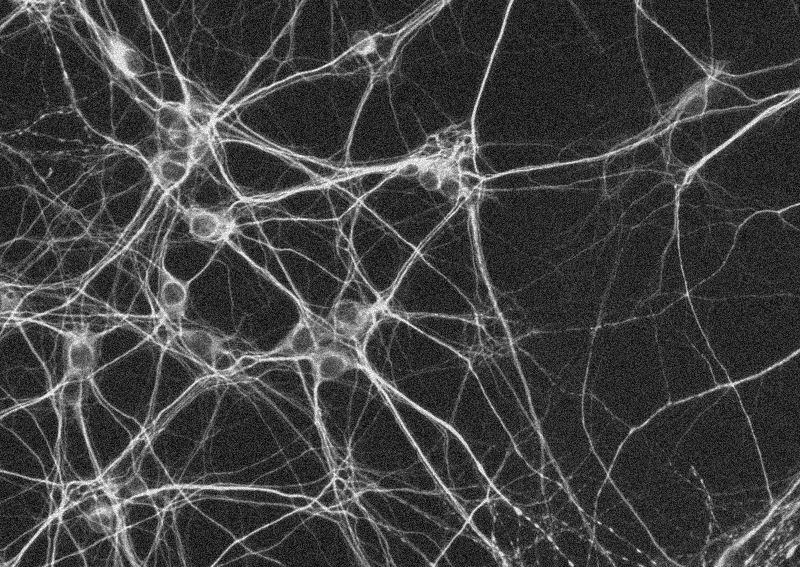

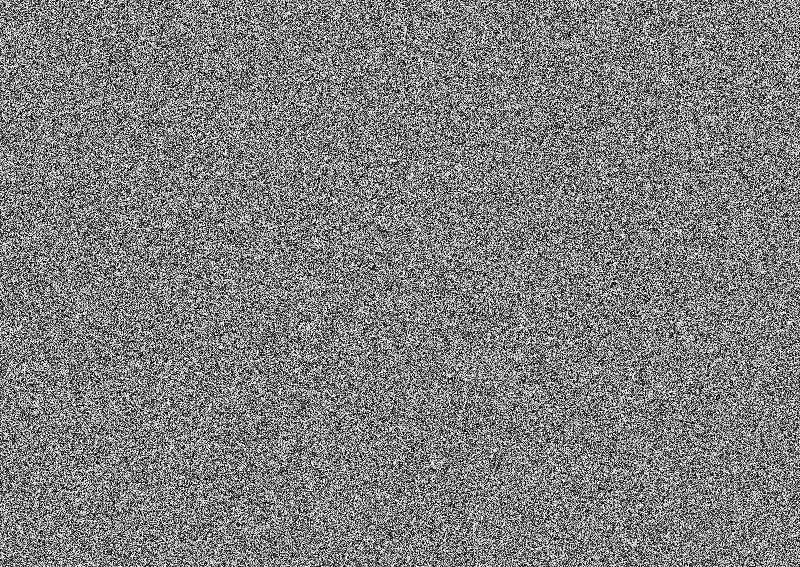

In [125]:
def to_uint8(vec, shape):
    v = vec.astype(np.float64).copy()
    v -= v.min()
    vmax = v.max()
    if vmax > 0:
        v /= vmax
    return (v * 255).astype(np.uint8).reshape(shape)

img1_u8 = to_uint8(S[0], shape1)
img2_u8 = to_uint8(S[1], shape1)

solution1 = Image.fromarray(img1_u8, mode="L")
solution2 = Image.fromarray(img2_u8, mode="L")
display(solution1)
display(solution2)